# Exploratory data analysis

In [1]:
import matplotlib.pyplot as plt
from sklearn_transformers import *
from pathlib import Path
from joblib import load
import pandas as pd

PREPROCESS_PATH = Path("data/preprocessed")
SAMPLE_SIZE = 10000
SPLIT_PATH = PREPROCESS_PATH / "splits"
TOKENIZER_PATH = PREPROCESS_PATH / "tokenizers"
SEED = 1234

In [2]:
data_path = PREPROCESS_PATH / "995k_rows_cleaned.csv"
df = pd.read_csv(data_path)
df.head(3)

,id,domain,type,url,content,title
0,7444726.0,nationalreview.com,political,http://www.nationalreview.com/node/152734/%E2%...,plus one article on google plus (thanks to ali...,iran news round up
1,6213642.0,beforeitsnews.com,fake,http://beforeitsnews.com/economy/2012/06/the-c...,the cost of the best senate banking committee ...,the cost of the best senate banking committee ...
2,3867639.0,dailycurrant.com,satire,http://dailycurrant.com/2016/01/18/man-awoken-...,man awoken from <NUM>-year coma commits suicid...,man awoken from <NUM>-year coma commits suicid...


## Type distribution
We will analyze the distribution of the ```type```-column using a pie chart

In [3]:
type_col = df["type"]
type_col.unique()

array(['political', 'fake', 'satire', 'reliable', 'conspiracy',
       'unreliable', 'bias', 'rumor', 'clickbait', 'hate', 'junksci'],
      dtype=object)

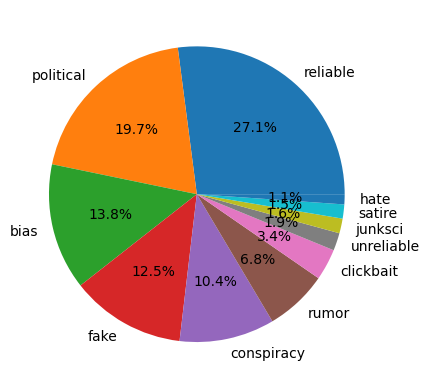

In [4]:
import matplotlib.pyplot as plt

counts = type_col.value_counts()
counts.plot(kind="pie", autopct='%1.1f%%')
plt.ylabel("")
plt.show()

It is clear that these labels are somewhat continuous, and from [Fake News Corpus](https://github.com/several27/FakeNewsCorpus), we can arrange them the following way, from most to least credible:
1. reliable
2. political
3. unreliable
4. clickbait
5. hate
6. junksci
7. conspiracy
8. bias
9. satire
10. fake


Clickbait is defined as ```Sources that provide generally credible content, but use exaggerated, misleading, or questionable headlines, social media descriptions, and/or images.```. Since it contains generally real information, we will set this at the point of differentiation for binary classification.

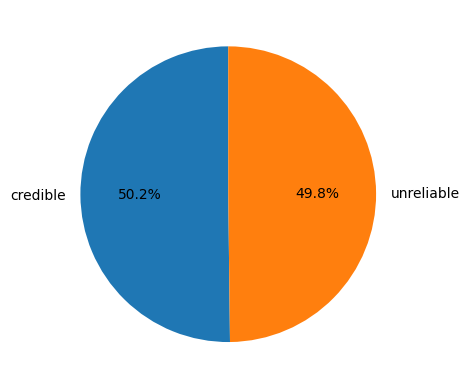

In [5]:
true_labels = ["reliable", "political", "clickbait"]
grouped = type_col.apply(lambda x: "credible" if x in true_labels else "unreliable")
counts = grouped.value_counts()
counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.ylabel("")
plt.show()

## Sources
We will analyze how the articles are distributed among the sources. This will uncover information about potential dominating sources etc..

Additionally, for each source/bar in the plot, we will colour code it into the different values of the ```type``` column in order to gain insights into how the type-values are distributed among the sources.

In [6]:
domains = df['domain'].unique()

top_20 = df["domain"].value_counts().head(20)
top_10 = top_20.head(10)

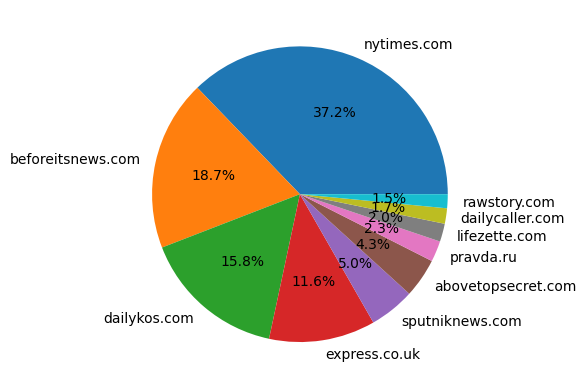

In [7]:
top_10.plot(kind="pie", autopct='%1.1f%%')
plt.ylabel("")
plt.show()

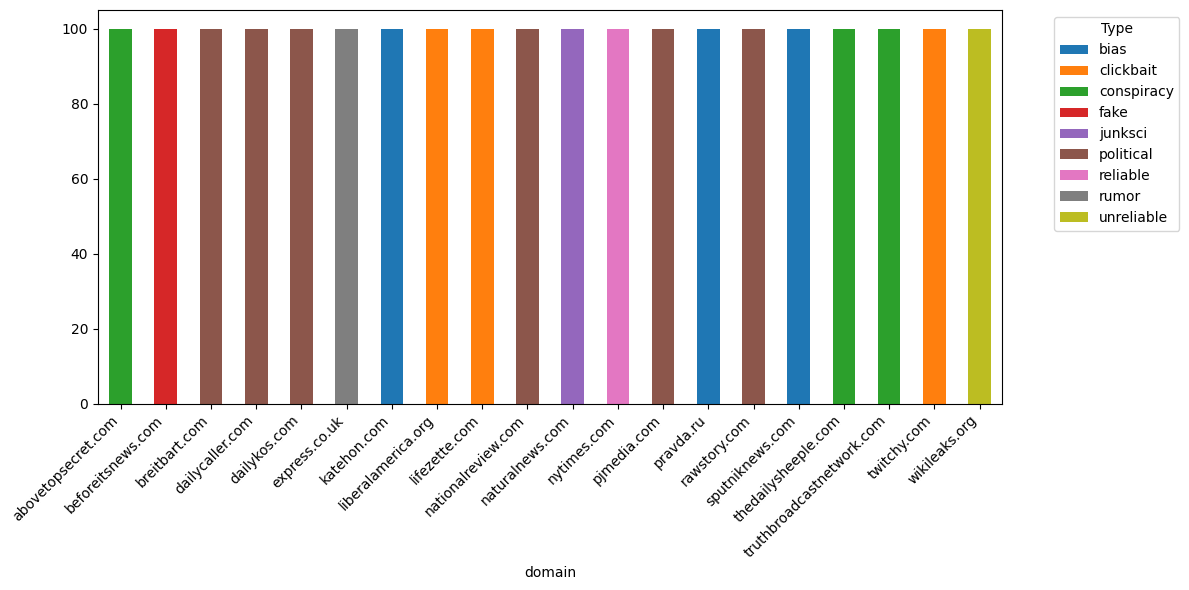

In [8]:
top_20_domains = df[df["domain"].isin(top_20.index)]
counts = (
    top_20_domains.groupby(["domain", "type"])
          .size()
          .unstack(fill_value=0)
)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100
percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)


plt.xticks(rotation=45, ha="right")
plt.legend(title="Type", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

It appears that each of the top 20 domains only have a single type value associated to them, meaning that the domain can carry a lot of signal about the type of an article.

## Zipf's law
We will be analyzing the different vocabularies (```nosw_nostem```, ```nostem```, both sw removal and stemming). To do this we will:
1. Compare their 100 most frequent tokens
2. Plot the frequencies of the tokens, to see if they follow a Zipfian distribution

Log-Log-diagram should appear as a straight line if the inverse-power-rule applies. That is, as seen bellow, not the case (no_stem_no_sw is close to straight).

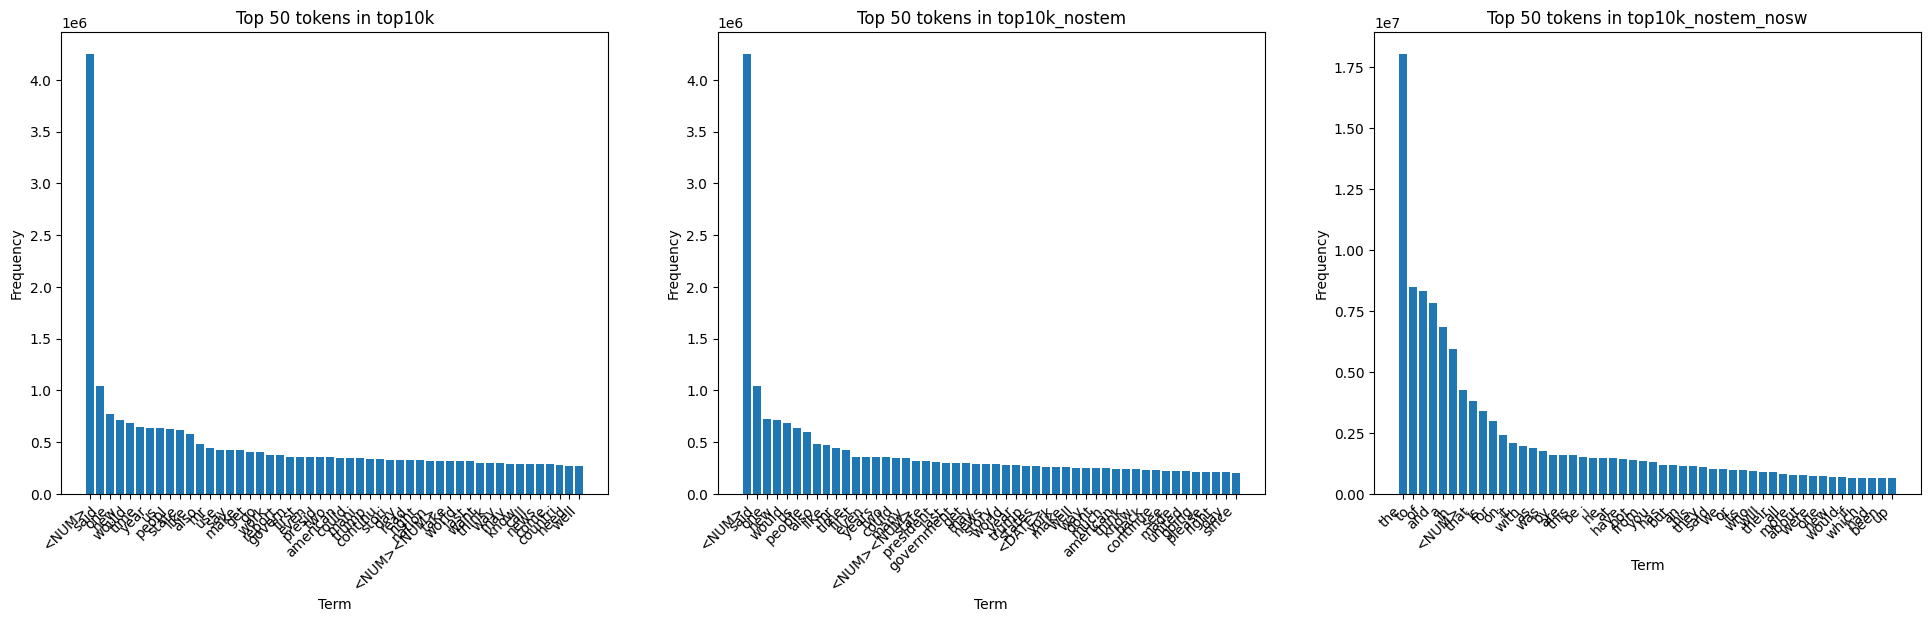

In [9]:
tokenizers = ["top10k", "top10k_nostem", "top10k_nostem_nosw"]
TOP_N = 50

def get_top_n(tokenizer_path, n):
    tokenizer : TokenTransformer = load(tokenizer_path)
    frequencies = tokenizer.token_frequencies.argsort()
    topn_indeces = frequencies[-n:]
    indeces_decr = topn_indeces[::-1]
    terms = [tokenizer.tokens[i].item() for i in indeces_decr]
    counts = [int(tokenizer.token_frequencies[i]) for i in indeces_decr]
    return (terms, counts)

fig, ax = plt.subplots(nrows=1,ncols=3, figsize=(24,6))

for i in range(3):
    topn = get_top_n(TOKENIZER_PATH / f"{tokenizers[i]}.joblib", TOP_N)

    ax[i].bar(*topn)
    ax[i].set_title(f"Top {TOP_N} tokens in {tokenizers[i]}")
    ax[i].set_xlabel("Term")
    ax[i].set_ylabel("Frequency")
    ax[i].tick_params(axis='x', rotation=45)
    plt.setp(ax[i].get_xticklabels(), rotation=45, ha='right')
    
plt.show()

To test for Zipf's law we plot frequencies on log-log-digram:

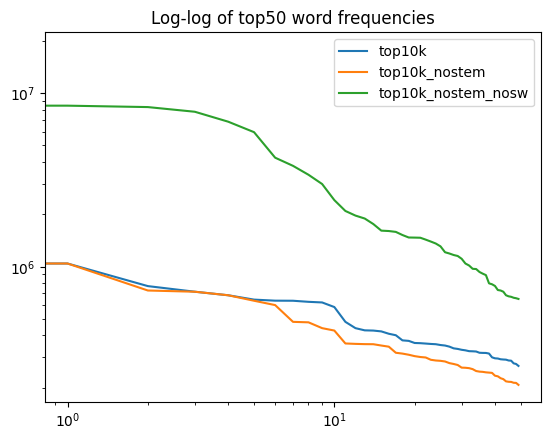

In [10]:
for i in range(3):
    topn = get_top_n(TOKENIZER_PATH / f"{tokenizers[i]}.joblib", TOP_N)
    plt.loglog(range(len(topn[1])), topn[1])

plt.title("Log-log of top50 word frequencies")
plt.legend(tokenizers)
plt.show()

This indicates that the removing the stopwords makes the frequencies inverse power distributed (follows Zipfs law), since exactly power distributions are straight lines on log-log diagrams.

## Article length analysis
We will sort the articles by their length (number of tokens) and plot this data with article length on the x-axis and number of articles with said length on the y-axis. It is assumed that this data will follow a normal distribution if initial sampling was perfectly random.

Additionally, we will attempt to cover any sort of correlation between an article's length and its "fakeness" score.

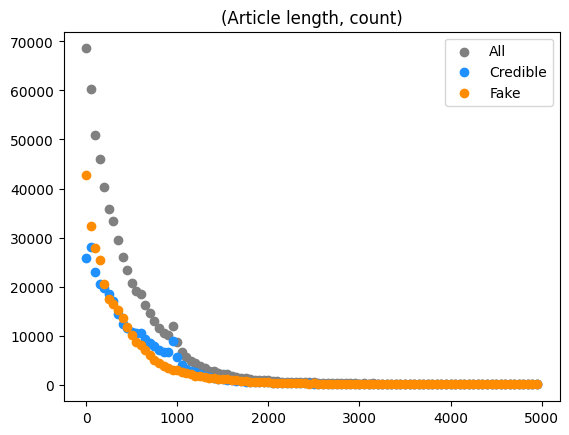

In [11]:
tokenized_training = pd.read_csv(SPLIT_PATH / "train.csv")

lengthCounts = [0] * 100
lengthCountsTrue = [0] * 100
lengthCountsFalse = [0] * 100

for i in range(tokenized_training.content.size):
    l = tokenized_training.content[i].split(" ").__len__() // 50
    if l > 99: continue

    lengthCounts[l] += 1
    if tokenized_training.type[i] in true_labels: lengthCountsTrue[l] += 1
    else: lengthCountsFalse[l] += 1

plt.title(label="(Article length, count)")
plt.scatter([i * 50 for i in range(100)], lengthCounts, c='grey', label="All")
plt.scatter([i * 50 for i in range(100)], lengthCountsTrue, c='dodgerblue', label="Credible")
plt.scatter([i * 50 for i in range(100)], lengthCountsFalse, c='darkorange', label="Fake")
plt.legend()
plt.show()

No clear correlation between length and credibility. Only a spike in the middle and a slight tendency for fake news to be shorter than credible.

# Final preprocessing step: Binary decision boundary
As dicussed in the type-section of this notebook, we group ```reliable```, ```political``` and ```clickbait``` into the group of non-fake news articles. We will now enforce this binary split on the training and evaluation data.

In [12]:
for split in ["train", "test", "val"]:
    file = SPLIT_PATH / f"{split}.csv"
    print("Processsing ", file)
    df = pd.read_csv(file)
    df["type"] = df["type"].astype("category")
    df["is_reliable"] = df["type"].isin(true_labels).astype(int)
    df.to_csv(file, index=False)

Processsing  data\preprocessed\splits\train.csv
Processsing  data\preprocessed\splits\test.csv
Processsing  data\preprocessed\splits\val.csv


In [13]:
df.head()

,id,domain,type,url,content,title,is_reliable
0,4927322.0,pravda.ru,bias,https://www.pravda.ru/accidents/03-10-2010/105...,"столичные ""зебры"" опасны для детей минувшее во...","столичные ""зебры"" опасны для детей",0
1,7123143.0,americablog.com,bias,http://americablog.com/2009/01/obama-signs-ord...,why does barack obama love the constitution? t...,obama signs order to close guantanamo in a year,0
2,9836763.0,nytimes.com,reliable,https://www.nytimes.com/2017/04/24/us/politics...,"hoping to pad the report card, he announced su...",trump wants it known: grading <NUM> days is ‘r...,1
3,2422578.0,twitchy.com,clickbait,https://twitchy.com/jennqpublic-3135/2013/04/2...,like gov. rick perry and anyone with even a sm...,amen: ted cruz on vile sac bee cartoon: ‘liber...,1
4,2968491.0,conservapedia.com,bias,http://www.conservapedia.com/Special:Log/Aweso...,combined display of all available logs of cons...,all public logs,0
